In [21]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as GridSpec
from scipy.stats import norm
import pickle
import sys
sys.path.append('../..')
sys.path.append('../../results')

from utils import *
from fig3.fig3_functions import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
# --- Load data (independent of fig2) ---
# Download from Zenodo [DOI] and place under data/fig2/
sigmas = ['sigma02', 'sigma05', 'sigma1']
data_root = '../../data/fig2'

data, data_normal = [], []
for s in sigmas:
    with open(f'{data_root}/{s}/Ws.pkl', 'rb') as f:
        data.append(pickle.load(f))
    with open(f'{data_root}/{s}/Ws_normal.pkl', 'rb') as f:
        data_normal.append(pickle.load(f))

solutions0 = [d for d in data[0] if not np.all(d.get('W') == 0)]
solutions1 = [d for d in data[1] if not np.all(d.get('W') == 0)]
solutions2 = [d for d in data[2] if not np.all(d.get('W') == 0)]

matrices0 = [d['W'] for d in solutions0]
matrices1 = [d['W'] for d in solutions1]
matrices2 = [d['W'] for d in solutions2]

L0 = [d['Lambda'] for d in solutions0]
L1 = [d['Lambda'] for d in solutions1]
L2 = [d['Lambda'] for d in solutions2]

matrices0_normal = [d['W_normal'] for d in data_normal[0]]
matrices1_normal = [d['W_normal'] for d in data_normal[1]]
matrices2_normal = [d['W_normal'] for d in data_normal[2]]

behaviours0 = np.load(f'{data_root}/behaviours/behaviours0.npy', allow_pickle=True).tolist()
behaviours1 = np.load(f'{data_root}/behaviours/behaviours1.npy', allow_pickle=True).tolist()
behaviours2 = np.load(f'{data_root}/behaviours/behaviours2.npy', allow_pickle=True).tolist()
behaviours_normal0 = np.load(f'{data_root}/behaviours/behaviours_normal0.npy', allow_pickle=True).tolist()
behaviours_normal1 = np.load(f'{data_root}/behaviours/behaviours_normal1.npy', allow_pickle=True).tolist()
behaviours_normal2 = np.load(f'{data_root}/behaviours/behaviours_normal2.npy', allow_pickle=True).tolist()

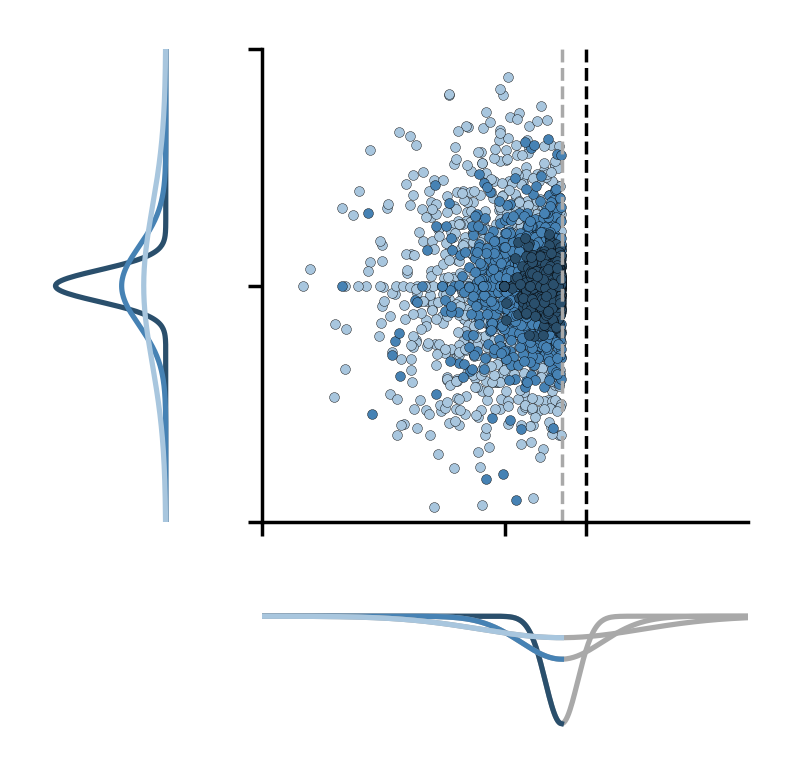

In [3]:
# --- Eigenvalue scatter with marginal distributions ---
ensembles = [
    ('σ = 0.2', solutions0, 0.2),
    ('σ = 0.5', solutions1, 0.5),
    ('σ = 1.0', solutions2, 1.0),
]
colors = ['#2a4f6c', '#4682B4', '#a8c6de']

rng = np.random.default_rng(0)
eigs_data = [(label, collect_eigs(sols, max_points=1000, rng=rng), sigma)
             for label, sols, sigma in ensembles]

fig = plt.figure(figsize=(1.8, 1.8), dpi=500)
gs = GridSpec.GridSpec(
    nrows=2, ncols=2,
    width_ratios=[1, 4], height_ratios=[4, 1],
    wspace=0.3, hspace=0.3
)
ax_left   = fig.add_subplot(gs[0, 0])
ax_main   = fig.add_subplot(gs[0, 1])
ax_bottom = fig.add_subplot(gs[1, 1])
ax_left.sharey(ax_main)
ax_bottom.sharex(ax_main)

x_min, x_max = -3.0, 3.0
y_min, y_max = -3.0, 3.0
ax_main.set_xlim(x_min, x_max)
ax_main.set_ylim(y_min, y_max)
mu_re, mu_im, boundary_re = 0.7, 0.0, 0.7

# scatter (reverse order so darkest on top)
for (label, eigs, sigma), color in zip(reversed(eigs_data), reversed(colors)):
    ax_main.scatter(eigs.real, eigs.imag, s=2, alpha=1,
                    color=color, edgecolor='k', linewidth=0.06)

# marginals (forward order)
for (label, eigs, sigma), color in zip(eigs_data, colors):
    x_grid = np.linspace(x_min, x_max, 400)
    pdf_re = norm.pdf(x_grid, loc=mu_re, scale=sigma)
    ax_bottom.plot(x_grid, -pdf_re, color='darkgray', linewidth=0.75)
    ax_bottom.plot(x_grid[x_grid <= boundary_re], -pdf_re[x_grid <= boundary_re],
                   color=color, linewidth=0.75)

    y_grid = np.linspace(y_min, y_max, 400)
    pdf_im = norm.pdf(y_grid, loc=mu_im, scale=sigma)
    ax_left.plot(-pdf_im, y_grid, color=color, linewidth=0.75)

ax_main.set_xticks([-3, 0, 1]); ax_main.set_xticklabels([])
ax_main.set_yticks([-3, 0, 3]); ax_main.set_yticklabels([])
ax_main.tick_params(length=2, width=0.5)
ax_main.axvline(1.0, color='k',        linestyle='--', linewidth=0.5)
ax_main.axvline(0.7, color='darkgray', linestyle='--', linewidth=0.5)
ax_main.spines['left'].set_linewidth(0.5)
ax_main.spines['bottom'].set_linewidth(0.5)
ax_main.spines['top'].set_visible(False)
ax_main.spines['right'].set_visible(False)
ax_left.axis('off')
ax_bottom.axis('off')
plt.show()

In [4]:
# --- Compute matrix metrics ---
cond0 = [np.linalg.cond(m) for m in matrices0]
cond1 = [np.linalg.cond(m) for m in matrices1]
cond2 = [np.linalg.cond(m) for m in matrices2]
cond0_normal = [np.linalg.cond(m) for m in matrices0_normal]
cond1_normal = [np.linalg.cond(m) for m in matrices1_normal]
cond2_normal = [np.linalg.cond(m) for m in matrices2_normal]

# LP solution norm (Henrici-style non-normality proxy)
H0 = [np.linalg.norm(d['sol']) for d in solutions0]
H1 = [np.linalg.norm(d['sol']) for d in solutions1]
H2 = [np.linalg.norm(d['sol']) for d in solutions2]
H0_normal = list(np.zeros(len(H0)))
H1_normal = list(np.zeros(len(H1)))
H2_normal = list(np.zeros(len(H2)))

# Frobenius norm
l20 = [np.linalg.norm(m) for m in matrices0]
l21 = [np.linalg.norm(m) for m in matrices1]
l22 = [np.linalg.norm(m) for m in matrices2]
l20_normal = [np.linalg.norm(m) for m in matrices0_normal]
l21_normal = [np.linalg.norm(m) for m in matrices1_normal]
l22_normal = [np.linalg.norm(m) for m in matrices2_normal]

# L1 norm
l10 = [np.sum(np.abs(m)) for m in matrices0]
l11 = [np.sum(np.abs(m)) for m in matrices1]
l12 = [np.sum(np.abs(m)) for m in matrices2]
l10_normal = [np.sum(np.abs(m)) for m in matrices0_normal]
l11_normal = [np.sum(np.abs(m)) for m in matrices1_normal]
l12_normal = [np.sum(np.abs(m)) for m in matrices2_normal]

In [23]:
# --- Compute proxy amplification (non-normal) ---
proxies = run_proxy_only_joblib(
    [matrices0, matrices1, matrices2],
    dt=0.005, T=20, tauE=0.1, tauI=0.1, n_jobs=-1
)

/Users/ncondruz/Desktop/PATNs/results/fig3/../../results/utils.py:536: ComplexWarning: Casting complex values to real discards the imaginary part
  x = np.array(x, dtype=float, copy=True)
/Users/ncondruz/Desktop/PATNs/results/fig3/../../results/utils.py:536: ComplexWarning: Casting complex values to real discards the imaginary part
  x = np.array(x, dtype=float, copy=True)
/Users/ncondruz/Desktop/PATNs/results/fig3/../../results/utils.py:536: ComplexWarning: Casting complex values to real discards the imaginary part
  x = np.array(x, dtype=float, copy=True)
/Users/ncondruz/Desktop/PATNs/results/fig3/../../results/utils.py:536: ComplexWarning: Casting complex values to real discards the imaginary part
  x = np.array(x, dtype=float, copy=True)
/Users/ncondruz/Desktop/PATNs/results/fig3/../../results/utils.py:536: ComplexWarning: Casting complex values to real discards the imaginary part
  x = np.array(x, dtype=float, copy=True)
/Users/ncondruz/Desktop/PATNs/results/fig3/../../results/uti

In [24]:
# --- Compute proxy amplification (normal) ---
proxies_normal = run_proxy_only_joblib(
    [matrices0_normal, matrices1_normal, matrices2_normal],
    dt=0.005, T=20, tauE=0.1, tauI=0.1, n_jobs=-1
)

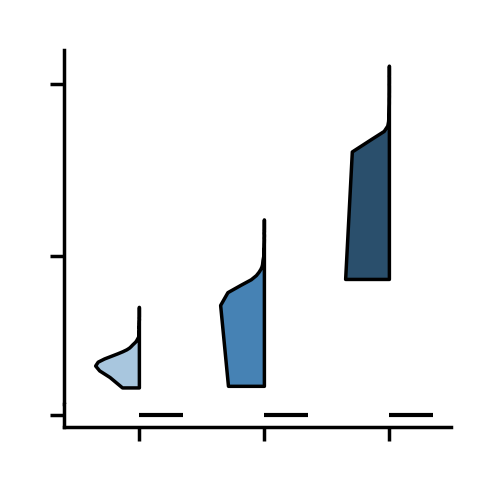

In [25]:
# --- MAIN TEXT: proxy amplification (broken axis — normal baseline = 0) ---
plot_half_violin(
    data_left  = [proxies[2],        proxies[1],        proxies[0]],
    data_right = [proxies_normal[2], proxies_normal[1], proxies_normal[0]],
    broken_axis=True, log_scale=True,
    yticks=[10e3, 10e7]
)

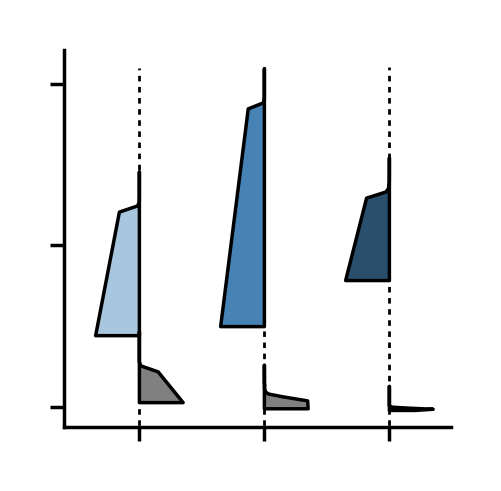

In [5]:
# --- SUPPLEMENTARY: condition number ---
plot_half_violin(
    data_left  = [cond2,        cond1,        cond0],
    data_right = [cond2_normal, cond1_normal, cond0_normal],
    broken_axis=False, log_scale=True,
    yticks=[1e2, 1e10, 1e18]
)

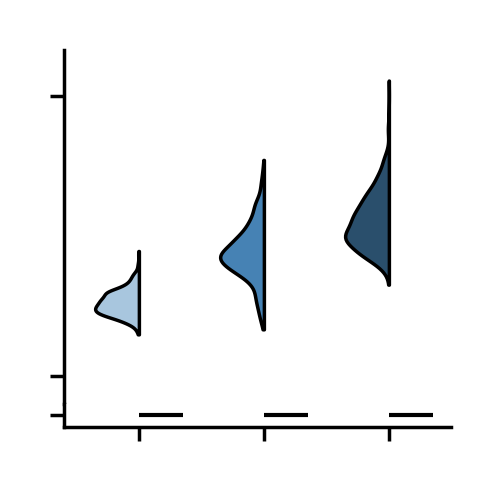

In [6]:
# --- SUPPLEMENTARY: LP solution norm (broken axis — normal baseline = 0) ---
plot_half_violin(
    data_left  = [H2, H1, H0],
    data_right = [H2_normal, H1_normal, H0_normal],
    broken_axis=True, log_scale=False,
    yticks=[30, 60], ylim=[27, 65]
)

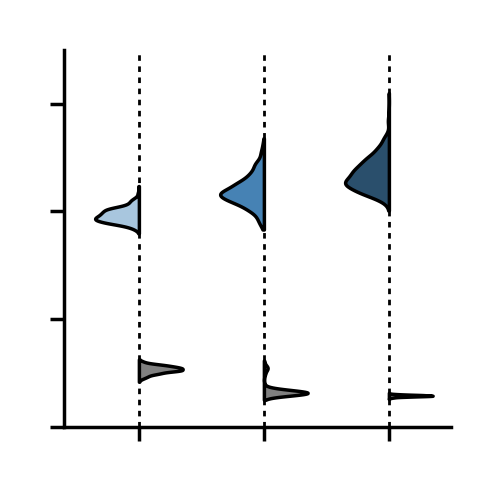

In [7]:
# --- SUPPLEMENTARY: Frobenius norm ---
plot_half_violin(
    data_left  = [l22,        l21,        l20],
    data_right = [l22_normal, l21_normal, l20_normal],
    broken_axis=False, log_scale=False,
    yticks=[0, 20, 40, 60], ylim=[0, 70]
)

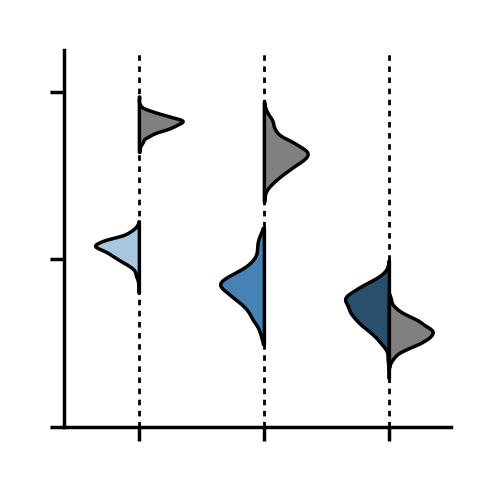

In [8]:
# --- SUPPLEMENTARY: L1/L2 ratio ---
l1l2_non    = [np.array(x) / np.array(y) for x, y in zip([l12, l11, l10],
                                                           [l22, l21, l20])]
l1l2_normal = [np.array(x) / np.array(y) for x, y in zip([l12_normal, l11_normal, l10_normal],
                                                           [l22_normal, l21_normal, l20_normal])]
plot_half_violin(
    data_left  = l1l2_non,
    data_right = l1l2_normal,
    broken_axis=False, log_scale=False,
    yticks=[0, 20, 40, 60], ylim=[20, 65]
)

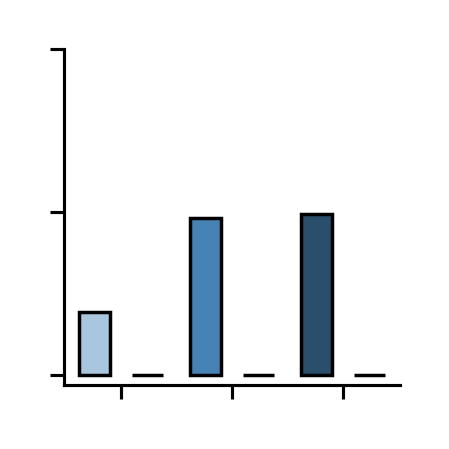

In [17]:
# --- Compute behavioural fractions ---
p_osc0, p_base0, p_newfp0, p_chaos0 = compute_fractions(behaviours0)
p_osc1, p_base1, p_newfp1, p_chaos1 = compute_fractions(behaviours1)
p_osc2, p_base2, p_newfp2, p_chaos2 = compute_fractions(behaviours2)
p_oscn0, p_basen0, p_newfpn0, p_chaosn0 = compute_fractions(behaviours_normal0)
p_oscn1, p_basen1, p_newfpn1, p_chaosn1 = compute_fractions(behaviours_normal1)
p_oscn2, p_basen2, p_newfpn2, p_chaosn2 = compute_fractions(behaviours_normal2)

# --- Oscillation fraction bar plot ---
plot_osc_fractions(
    p_osc_non_normal = [p_osc2,  p_osc1,  p_osc0],
    p_osc_normal     = [p_oscn2, p_oscn1, p_oscn0]
)

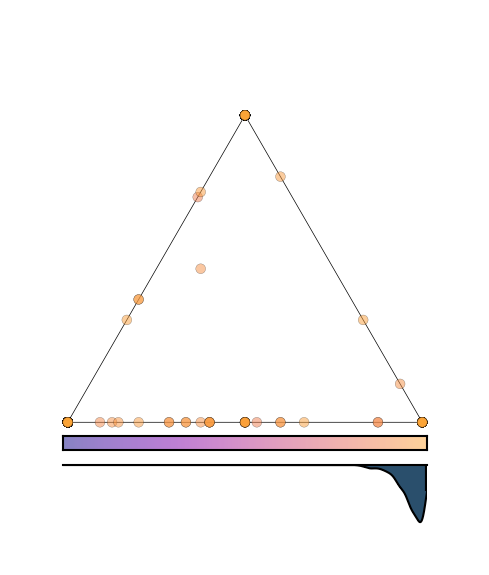

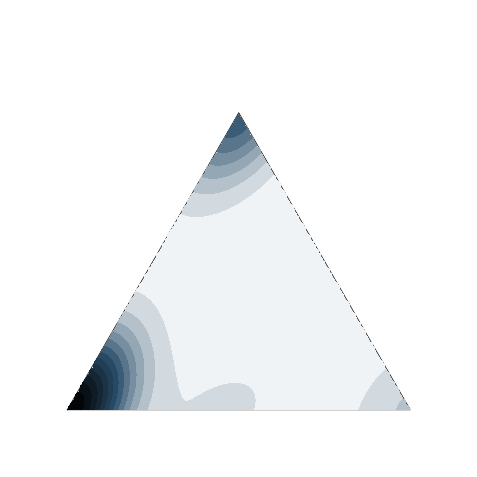

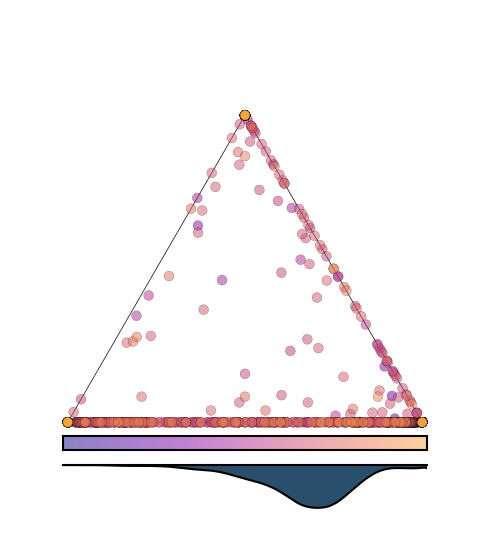

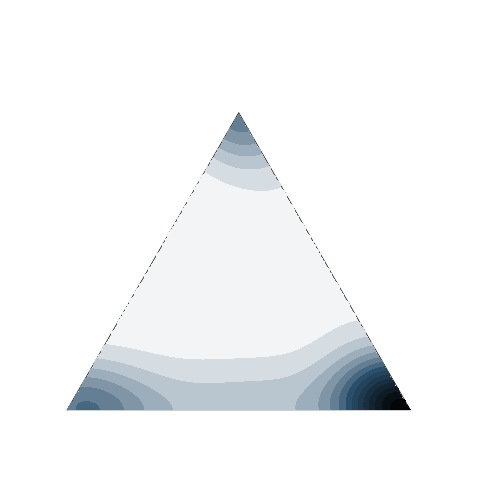

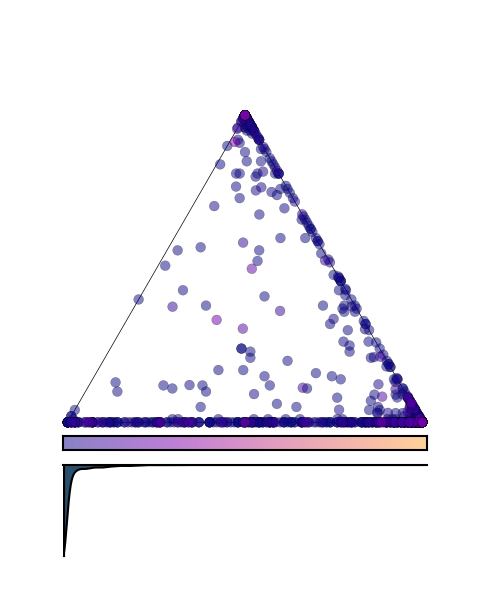

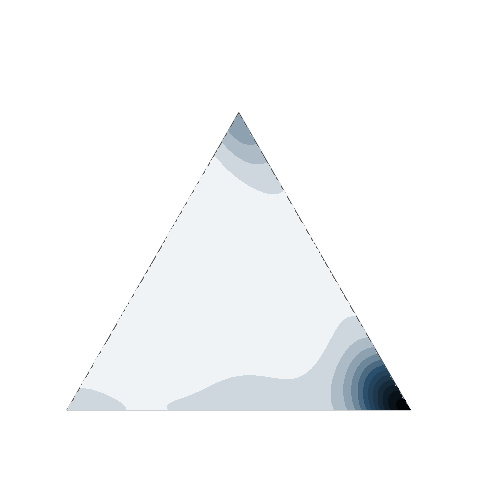

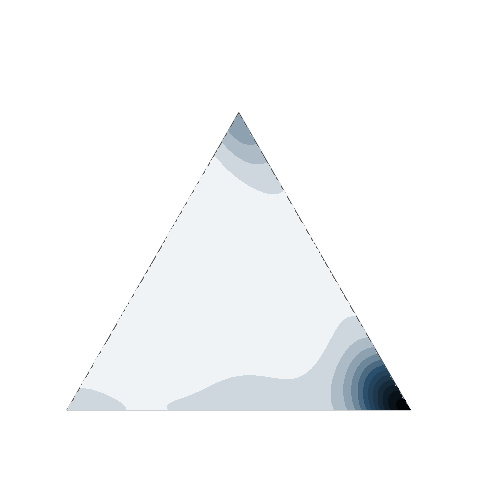

In [22]:
# --- Ternary plots: sigma = 1.0 ---
fig, axes = plot_ternary_main_with_cbar_and_baseline_pdf(
    p_osc2, p_base2, p_newfp2, p_chaos2,
    cbar_shrink=0.935, cbar_thickness=0.8, pdf_height=0.12, gap=0.03)
plot_ternary_kde_only(p_osc2, p_base2, p_newfp2, p_chaos2)

# --- Ternary plots: sigma = 0.5 ---
fig, axes = plot_ternary_main_with_cbar_and_baseline_pdf(
    p_osc1, p_base1, p_newfp1, p_chaos1,
    cbar_shrink=0.935, cbar_thickness=0.8, pdf_height=0.09, gap=0.03)
plot_ternary_kde_only(p_osc1, p_base1, p_newfp1, p_chaos1)

# --- Ternary plots: sigma = 0.2 ---
fig, axes = plot_ternary_main_with_cbar_and_baseline_pdf(
    p_osc0, p_base0, p_newfp0, p_chaos0,
    cbar_shrink=0.935, cbar_thickness=0.8, pdf_height=0.19, gap=0.03)
plot_ternary_kde_only(p_osc0, p_base0, p_newfp0, p_chaos0)